[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_06/assignments/assignment_combined_5_6.ipynb)

# Assignment 5 & 6: HRTEM Simulation and CTF Analysis

In this assignment, you will use the `abTEM` package to perform a multislice High-Resolution Transmission Electron Microscopy (HRTEM) simulation. You will build an atomic model, calculate its projected potential, simulate the electron wave propagation, and apply different Contrast Transfer Functions (CTFs) to understand how microscope parameters affect the final image.

## Learning Objectives
1. Understand the multislice algorithm for HRTEM simulation.
2. Explore the effects of the Contrast Transfer Function (CTF), including spherical aberration ($C_s$) and defocus ($\Delta f$).
3. Analyze the impact of aberration correction and noise on image quality.

---

## Part 1: Setup and Building the Atomic Model

First, we import the necessary libraries and build our atomic model. We will use a Silicon Nitride (Si$_3$N$_4$) crystal structure.

In [2]:
%matplotlib inline

import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt

print(f"abTEM version: {abtem.__version__}")

abTEM version: 1.0.9


### Define the Si$_3$N$_4$ Structure
We use the Atomic Simulation Environment (`ase`) to define the unit cell by providing the atomic positions and cell dimensions.

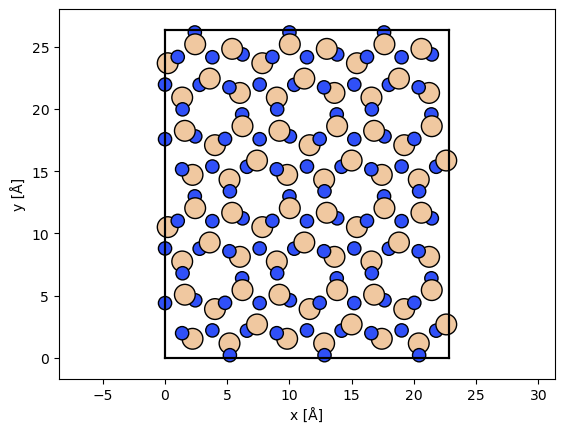

In [5]:
structure = ase.Atoms(
    'Si6N8',
    positions=[
      (4.015308131006949, 3.9110253242355126, 2.1788993100000003),
      (2.422878997737693, -1.15285715796029, 0.72629977),
      (5.3947013511357, -1.5218461833564767, 0.72629977),
      (2.2098430845971873, 1.521846183356477, 2.1788993100000003),
      (5.181665437995193, 1.1528571579602902, 2.1788993100000003),
      (3.5892363047259375, -3.9110253242355126, 0.72629977),
      (3.8022722178664434, 2.195242888517426, 2.1788993100000003),
      (3.802272217866444, -2.1952428885174267, 0.72629977),
      (6.2321062558996125, -1.9713791971906662, 2.1788993100000003),
      (4.8233175932090955, 4.411472738097657, 0.72629977),
      (5.211060880556961, 0.20287673026395847, 0.72629977),
      (2.3934835551759255, -0.20287673026395803, 2.1788993100000003),
      (1.3724381798332734, 1.9713791971906653, 0.72629977),
      (2.781226842523792, -4.411472738097657, 2.1788993100000003),
    ],
    cell=[7.6045, 7.6045, 2.9052, 90, 90, 120]
)

# The multislice algorithm requires an orthogonal input cell.
structure_orthogonal = abtem.orthogonalize_cell(structure)

# Visualize the orthogonalized structure (tiled 3x2x6 for visualization)
abtem.show_atoms(structure_orthogonal * (3,2,6), plane='xy');

---

## Part 2: Calculate Projected Potentials

**TASK 1:** Calculate the projected potentials for the structure.
1. Create a `FrozenPhonons` object using the orthogonalized structure tiled by `(3, 2, 17)`. This gives a thickness of ~5 nm. Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N.
2. Create a `Potential` object using the frozen phonons, with a sampling of 0.1 Å, slice thickness of 2.0 Å, and the 'kirkland' parametrization.
3. Plot the mean-projected potential.

tasks:   0%|          | 0/17 [00:00<?, ?it/s]

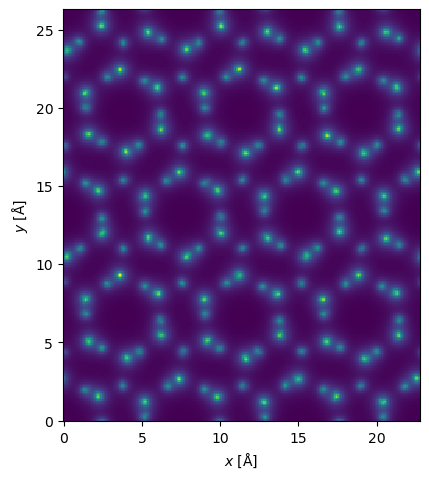

In [6]:
# TASK 1: Create FrozenPhonons
# Tile the structure by (3, 2, 17) to get ~5 nm thickness
# Use 8 configurations and a thermal sigma of 0.1 Å for both Si and N
frozen_phonons = abtem.FrozenPhonons(
    structure_orthogonal * (3, 2, 17),
    num_configs=8,
    sigmas={'Si': 0.1, 'N': 0.1},  # thermal displacement in Å
)

# TASK 1: Create the Potential object
# Use sampling=0.1 Å, slice_thickness=2.0 Å, and the 'kirkland' parametrization
potential = abtem.Potential(
    frozen_phonons,
    sampling=0.1,           # real-space sampling in Å/pixel
    slice_thickness=2.0,    # thickness of each projected slice in Å
    parametrization='kirkland',
)

# TASK 1: Plot the mean projected potential
# .project() collapses along z; .show() displays it
potential.project().show(cmap='viridis');


---

## Part 3: HRTEM Plane Wave Multislice Simulation

**TASK 2:** Perform the multislice simulation.
1. Initialize a `PlaneWave` with an energy of 300 keV.
2. Run the `multislice` algorithm using the potential you calculated.
3. Plot the mean intensity of the exit waves.

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

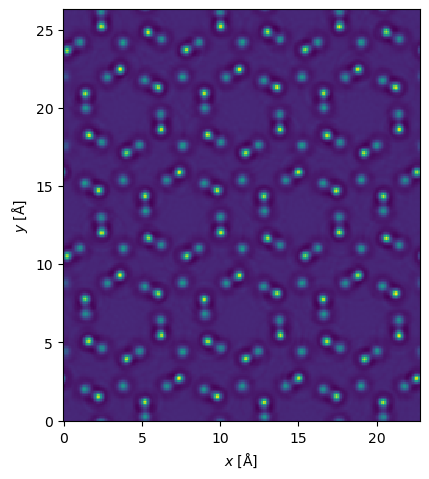

In [7]:
# TASK 2: Initialize the PlaneWave with 300 keV energy
wave = abtem.PlaneWave(energy=300e3)  # energy in eV

# TASK 2: Run the multislice simulation
# This propagates the wave through each slice of the potential
exit_waves = wave.multislice(potential)

# TASK 2: Plot the mean intensity of the exit waves
# .intensity() computes |ψ|², .mean(0) averages over frozen phonon configs
exit_waves.intensity().mean(0).show(cmap='viridis');


---

## Part 4: Contrast Transfer Function (CTF)

The exit wave represents the electron wave immediately after leaving the sample. To simulate the final image, we must apply the Contrast Transfer Function (CTF) of the microscope.

**TASK 3:** Define and apply different CTFs.
1. Define an **uncorrected CTF** with $C_{10} = -600$ Å (defocus) and $C_{30} = 1.3 \times 10^7$ Å ($C_s = 1.3$ mm).
2. Define an **aberration-corrected CTF** with $C_{10} = 30$ Å and $C_{30} = -8 \times 10^4$ Å.
3. Plot both CTFs to compare them.
4. Apply both CTFs to your `exit_waves` and plot the resulting mean image intensities.

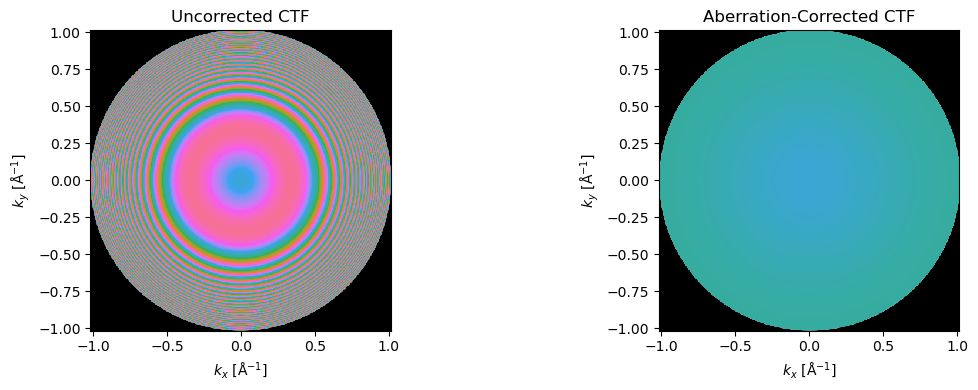

In [12]:
# --- TASK 3a: Define the UNCORRECTED CTF ---
parameters_uncorrected = {
    'C10': -600,        # defocus in Å
    'C30': 1.3e7,       # Cs in Å
}

# 修正：加入 gpts=512 或 sampling 參數，確保繪圖網格的分母不為 0
ctf_uncorrected = abtem.CTF(
    energy=300e3, 
    gpts=512,           # 手動指定網格點數
    semiangle_cutoff=20, # 限制截止半角（mrad）有助於穩定繪圖
    **parameters_uncorrected
)

# --- TASK 3b: Define the ABERRATION-CORRECTED CTF ---
parameters_corrected = {
    'C10': 30,          
    'C30': -8e4,        
}

# 同樣加入網格定義
ctf_corrected = abtem.CTF(
    energy=300e3, 
    gpts=512, 
    semiangle_cutoff=20, 
    **parameters_corrected
)

# --- TASK 3c: Plot both CTFs ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 指定 max_angle 可以進一步確保繪圖計算範圍正確
ctf_uncorrected.show(ax=axes[0], max_angle=20) 
axes[0].set_title('Uncorrected CTF')

ctf_corrected.show(ax=axes[1], max_angle=20)
axes[1].set_title('Aberration-Corrected CTF')

plt.tight_layout()
plt.show()

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

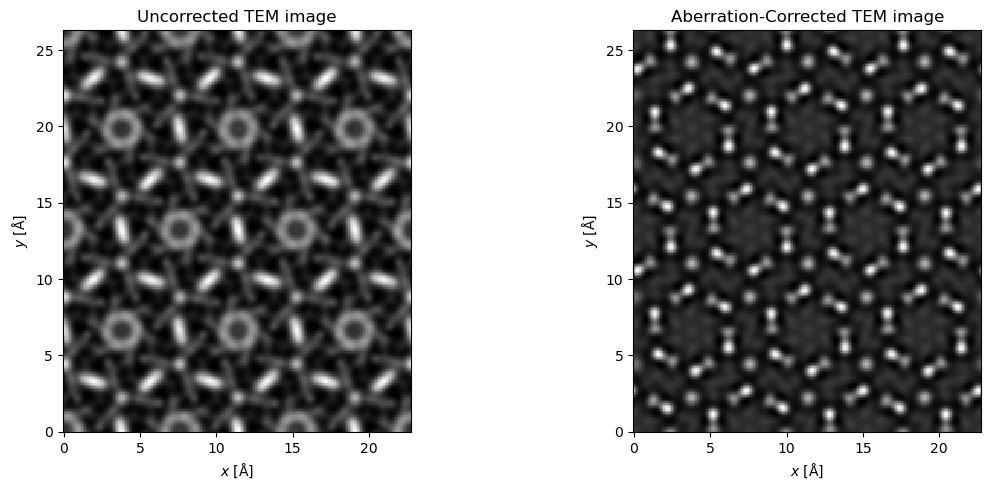

In [13]:
# TASK 3d: Apply each CTF to the exit waves
# .apply_ctf() convolves the exit wave with the CTF in Fourier space
image_uncorrected = exit_waves.apply_ctf(ctf_uncorrected)
image_corrected   = exit_waves.apply_ctf(ctf_corrected)

# TASK 3d: Plot the resulting mean image intensities side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

image_uncorrected.intensity().mean(0).show(cmap='gray', ax=axes[0])
axes[0].set_title('Uncorrected TEM image')

image_corrected.intensity().mean(0).show(cmap='gray', ax=axes[1])
axes[1].set_title('Aberration-Corrected TEM image')

plt.tight_layout()
plt.show()


---

## Part 5: Noise and Dose

Real TEM images are affected by Poisson noise due to the finite electron dose.

**TASK 4:** Apply Poisson noise to your images.
1. Use `abtem.noise.poisson_noise` to apply a dose of $100$ $e^-$/Å$^2$ to your aberration-corrected image.
2. Plot the noisy image alongside the noiseless one for comparison.

tasks:   0%|          | 0/32 [00:00<?, ?it/s]

tasks:   0%|          | 0/33 [00:00<?, ?it/s]

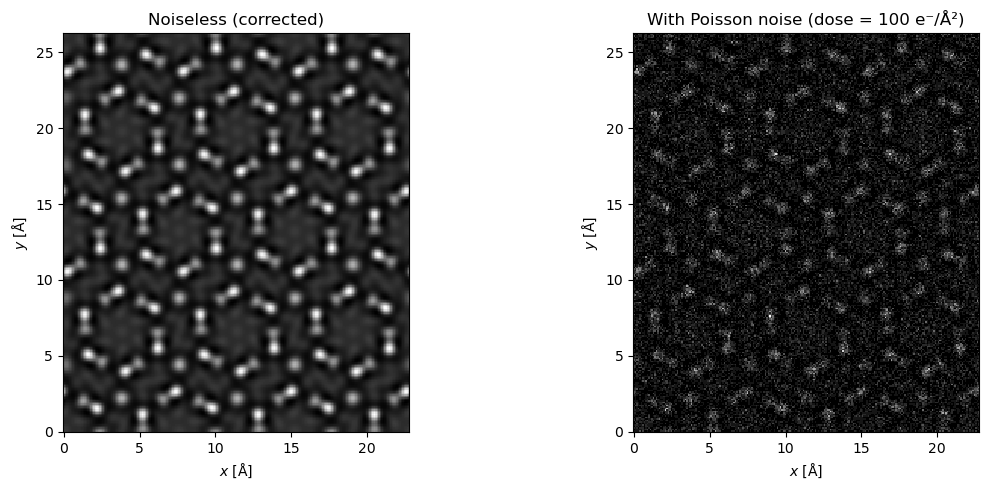

In [17]:
# TASK 4: Apply Poisson noise to the aberration-corrected image
# Define the dose value in electrons per Å²
dose_value = 100 

# First get the noiseless mean intensity image
noiseless_image = image_corrected.intensity().mean(0)

# Fix: Try passing the dose as a positional argument if keyword arguments fail.
# In many abtem versions, the first argument of poisson_noise is the dose.
noisy_image = noiseless_image.poisson_noise(dose_value)

# TASK 4: Plot the noiseless vs noisy images side by side for comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

noiseless_image.show(cmap='gray', ax=axes[0])
axes[0].set_title(f'Noiseless (corrected)')

noisy_image.show(cmap='gray', ax=axes[1])
axes[1].set_title(f'With Poisson noise (dose = {dose_value} e⁻/Å²)')

plt.tight_layout()
plt.show()

---

# Task 6: Self-Reflection

Based on your simulations above, answer the following questions:

**1. Contrast Transfer Function (CTF):**
- How does the uncorrected CTF differ from the aberration-corrected CTF in terms of spatial frequency transfer?
- Why do we see sharper atomic columns in the aberration-corrected image?

**2. Defocus and Contrast:**
- Why don't we typically image at exactly zero defocus ($\Delta f = 0$) in a conventional (uncorrected) TEM?
- What is the significance of the Scherzer defocus?

**3. Simulation vs. Reality:**
- How does adding Poisson noise change the interpretability of the image?
- What other experimental factors (not simulated here) might degrade the quality of a real HRTEM image?

**4. Multislice Algorithm:**
- Why is the multislice method necessary for a 5 nm thick sample, rather than just using a single projected potential (kinematic approximation)?

### Your Answers:

**1. Contrast Transfer Function (CTF):**
- How does the uncorrected CTF differ from the aberration-corrected CTF in terms of spatial frequency transfer?

  *The uncorrected CTF exhibits rapid oscillations and a premature damping at high spatial frequencies due to spherical aberration ($C_{30}$). In contrast, the aberration-corrected CTF provides a much broader and more stable "passband," allowing a wider range of spatial frequencies to be transferred with consistent phase.*
  
- Why do we see sharper atomic columns in the aberration-corrected image?

    *Correction of $C_{30}$ minimizes the delocalization of information and narrows the Point Spread Function (PSF). This concentration of electron intensity directly onto the atomic sites results in higher resolution and sharper visual definition of the columns.*

**2. Defocus and Contrast:**
- Why don't we typically image at exactly zero defocus ($\Delta f = 0$) in a conventional (uncorrected) TEM?

    *In a conventional TEM, a perfectly focused image of a weak phase object yields near-zero contrast. Controlled defocus is necessary to introduce a phase shift that converts phase variations of the electron wave into detectable intensity variations (amplitude contrast).*
  
- What is the significance of the Scherzer defocus?

  *It represents the optimal underfocus value ($\Delta f = -1.2 \sqrt{C_s \lambda}$) where the phase shift from defocus balances the phase shift from spherical aberration. This creates a maximal "plateau" in the CTF, providing a directly interpretable image up to the point resolution of the microscope.*

**3. Simulation vs. Reality:**
- How does adding Poisson noise change the interpretability of the image?

  *Adding Poisson noise simulates the quantum nature of electrons. High noise levels (low dose) reduce the Signal-to-Noise Ratio (SNR), potentially masking subtle structural features like point defects or strain, and can even introduce artifacts that resemble atomic features.*
  
- What other experimental factors (not simulated here) might degrade the quality of a real HRTEM image?

  *Real-world HRTEM quality is further limited by temporal incoherence (chromatic aberration $C_c$ and energy spread), spatial incoherence (source size), mechanical vibrations, drift, electromagnetic interference, and surface amorphous contamination on the specimen.*  

**4. Multislice Algorithm:**
- Why is the multislice method necessary for a 5 nm thick sample, rather than just using a single projected potential (kinematic approximation)?

  *The single projected potential (kinematic approximation) assumes a very thin sample where multiple scattering is negligible. For a 5 nm specimen, dynamical scattering effects become significant. The multislice algorithm accounts for the evolution of the electron wavefunction as it propagates through the crystal, capturing the continuous redistribution of intensity between the transmitted and diffracted beams which a simple projection would fail to model.*